---
# 1. Load Previous Data




In [1]:
# Import pandas for data manipulation using dataframes
import pandas as pd

# Import numpy for numerical array operations
import numpy as np

# Import matplotlib for creating visualization charts
import matplotlib.pyplot as plt

# Import seaborn for beautiful statistical plots
import seaborn as sns

# Import os for operating system directory paths
import os

# Import joblib for saving and loading trained models
import joblib

# Import Scikit-Learn regression models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Import Scikit-Learn evaluation metrics
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Import Scikit-Learn pipeline components
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Set seaborn theme style for clean visual graphs
sns.set_theme(style="whitegrid")

# Configure pandas to display all columns
pd.set_option("display.max_columns", None)

print("All libraries imported successfully!")

All libraries imported successfully!


### Loading Preprocessed Datasets from `data/processed/`



In [2]:
# Define directory path where processed files are stored
processed_dir = os.path.join("..", "data", "processed")

# Fallback path if notebook is run directly from project root directory
if not os.path.exists(processed_dir):
    processed_dir = os.path.join("data", "processed")

print("Loading preprocessed datasets from:", processed_dir)

# Load feature matrices (X_train and X_test)
X_train = pd.read_csv(os.path.join(processed_dir, "X_train.csv"))
X_test = pd.read_csv(os.path.join(processed_dir, "X_test.csv"))

# Load target values (y_train and y_test)
y_train_df = pd.read_csv(os.path.join(processed_dir, "y_train.csv"))
y_test_df = pd.read_csv(os.path.join(processed_dir, "y_test.csv"))

# Extract target values as 1D arrays for Scikit-Learn models
y_train = y_train_df.values.ravel()
y_test = y_test_df.values.ravel()

print("All datasets loaded successfully!")
print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape: ", y_test.shape)

# Display first 5 rows of X_train
X_train.head()

Loading preprocessed datasets from: ..\data\processed
All datasets loaded successfully!
X_train shape: (2335, 224)
X_test shape:  (584, 224)
y_train shape: (2335,)
y_test shape:  (584,)


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,ExterCond,BsmtQual,BsmtCond,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,HeatingQC,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Fireplaces,FireplaceQu,GarageYrBlt,GarageCars,GarageArea,GarageQual,GarageCond,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,MiscVal,MoSold,YrSold,MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Pave,Alley_None,Alley_Pave,LotShape_IR2,LotShape_IR3,LotShape_Reg,LandContour_HLS,LandContour_Low,LandContour_Lvl,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,LandSlope_Mod,LandSlope_Sev,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Condition1_Feedr,Condition1_Norm,Condition1_PosA,Condition1_PosN,Condition1_RRAe,Condition1_RRAn,Condition1_RRNe,Condition1_RRNn,Condition2_Feedr,Condition2_Norm,Condition2_PosA,Condition2_PosN,Condition2_RRAe,Condition2_RRAn,Condition2_RRNn,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,RoofStyle_Gable,RoofStyle_Gambrel,RoofStyle_Hip,RoofStyle_Mansard,RoofStyle_Shed,RoofMatl_CompShg,RoofMatl_Membran,RoofMatl_Roll,RoofMatl_Tar&Grv,RoofMatl_WdShake,RoofMatl_WdShngl,Exterior1st_AsphShn,Exterior1st_BrkComm,Exterior1st_BrkFace,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing,Exterior2nd_AsphShn,Exterior2nd_Brk Cmn,Exterior2nd_BrkFace,Exterior2nd_CBlock,Exterior2nd_CmentBd,Exterior2nd_HdBoard,Exterior2nd_ImStucc,Exterior2nd_MetalSd,Exterior2nd_Other,Exterior2nd_Plywood,Exterior2nd_Stone,Exterior2nd_Stucco,Exterior2nd_VinylSd,Exterior2nd_Wd Sdng,Exterior2nd_Wd Shng,MasVnrType_BrkFace,MasVnrType_None,MasVnrType_Stone,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,BsmtExposure_Gd,BsmtExposure_Mn,BsmtExposure_No,BsmtExposure_None,BsmtFinType1_BLQ,BsmtFinType1_GLQ,BsmtFinType1_LwQ,BsmtFinType1_None,BsmtFinType1_Rec,BsmtFinType1_Unf,BsmtFinType2_BLQ,BsmtFinType2_GLQ,BsmtFinType2_LwQ,BsmtFinType2_None,BsmtFinType2_Rec,BsmtFinType2_Unf,Heating_GasW,Heating_Grav,Heating_OthW,Heating_Wall,CentralAir_Y,Electrical_FuseF,Electrical_FuseP,Electrical_Mix,Electrical_SBrkr,Functional_Maj2,Functional_Min1,Functional_Min2,Functional_Mod,Functional_Sev,Functional_Typ,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageType_None,GarageFinish_None,GarageFinish_RFn,GarageFinish_Unf,PavedDrive_P,PavedDrive_Y,Fence_GdWo,Fence_MnPrv,Fence_MnWw,Fence_None,MiscFeature_None,MiscFeature_Othr,MiscFeature_Shed,MiscFeature_TenC,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,2.414130,-3.467390,-1.093963,-0.069779,-0.506747,0.145606,-0.392616,-0.564441,-0.682976,-0.227474,0.583789,0.134419,-0.812290,-0.300679,0.505108,-0.446516,-0.157528,-0.769269,0.635565,-0.096017,-0.078952,-0.822222,-0.252943,0.793187,1.249196,0.179037,-0.202064,-0.776728,-0.287746,0.618158,0.675581,0.234788,0.306617,-0.055082,0.273819,0.264060,-0.742344,-0.283719,-0.350299,-0.104723,-0.283594,-0.065732,-0.056139,-0.091358,0.281004,-1.354342,False,False,True,

---
# 2. Understand Training And Testing Data



In [3]:
# Total number of houses across train and test sets
total_houses = X_train.shape[0] + X_test.shape[0]

train_percentage = (X_train.shape[0] / total_houses) * 100
test_percentage = (X_test.shape[0] / total_houses) * 100

print(f"Dataset Split Summary:")
print(f"  Total Houses: {total_houses}")
print(f"  Training Set (X_train): {X_train.shape[0]} houses ({train_percentage:.1f}%)")
print(f"  Testing Set  (X_test) : {X_test.shape[0]} houses ({test_percentage:.1f}%)")
print(f"  Number of Features    : {X_train.shape[1]} columns")

Dataset Split Summary:
  Total Houses: 2919
  Training Set (X_train): 2335 houses (80.0%)
  Testing Set  (X_test) : 584 houses (20.0%)
  Number of Features    : 224 columns


---
# 3. Explain Regression Models


---
# 4. Create Preprocessing Pipeline


In [4]:
# Example of a Scikit-Learn Pipeline combining scaling and Linear Regression
sample_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

print("Sample Scikit-Learn Pipeline structure:")
print(sample_pipeline)

Sample Scikit-Learn Pipeline structure:
Pipeline(steps=[('scaler', StandardScaler()), ('model', LinearRegression())])


---
# 5. Train Model 1: Linear Regression


In [5]:
# Step 1: Create Linear Regression model object
model_lr = LinearRegression()

# Step 2: Train the model on training data
model_lr.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

# Step 3: Predict prices on testing data
y_pred_lr = model_lr.predict(X_test)

# Step 4: Create a side-by-side comparison DataFrame for the first 10 test houses
comparison_lr = pd.DataFrame({
    'Real Price ($)': y_test[:10],
    'Predicted Price ($)': np.round(y_pred_lr[:10], 2),
    'Difference ($)': np.round(y_pred_lr[:10] - y_test[:10], 2)
})

print("\nLinear Regression Predictions (First 10 Test Houses):")
comparison_lr

Linear Regression model trained successfully!

Linear Regression Predictions (First 10 Test Houses):


,Real Price ($),Predicted Price ($),Difference ($)
0,180096.931198,-151164.37,-331261.30
1,192686.931748,-89905.43,-282592.36
2,158151.985049,-151129.80,-309281.79
3,187500.000000,-70149.88,-257649.88
4,172023.677782,-98438.36,-270462.04
5,311872.000000,-32381.18,-344253.18
6,154034.917446,-176335.40,-330370.31
7,260000.000000,232567.34,-27432.66
8,185998.255166,-164809.70,-350807.95
9,181613.035129,87330.30,-94282.74


---
# 6. Train Model 2: Random Forest Regressor


In [6]:
# Step 1: Create Random Forest Regressor model object (with 100 trees)
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)

# Step 2: Train the model on training data
model_rf.fit(X_train, y_train)

print("Random Forest Regressor trained successfully!")

# Step 3: Predict prices on testing data
y_pred_rf = model_rf.predict(X_test)

# Step 4: Create a side-by-side comparison DataFrame for the first 10 test houses
comparison_rf = pd.DataFrame({
    'Real Price ($)': y_test[:10],
    'Predicted Price ($)': np.round(y_pred_rf[:10], 2),
    'Difference ($)': np.round(y_pred_rf[:10] - y_test[:10], 2)
})

print("\nRandom Forest Predictions (First 10 Test Houses):")
comparison_rf

Random Forest Regressor trained successfully!

Random Forest Predictions (First 10 Test Houses):


,Real Price ($),Predicted Price ($),Difference ($)
0,180096.931198,141512.45,-38584.48
1,192686.931748,203775.66,11088.73
2,158151.985049,147012.17,-11139.82
3,187500.000000,208984.73,21484.73
4,172023.677782,195723.21,23699.53
5,311872.000000,225970.25,-85901.75
6,154034.917446,120261.22,-33773.70
7,260000.000000,203092.71,-56907.29
8,185998.255166,144852.29,-41145.96
9,181613.035129,173205.09,-8407.94


---
# 7. Train Model 3: Gradient Boosting Regressor


In [7]:
# Step 1: Create Gradient Boosting Regressor model object
model_gb = GradientBoostingRegressor(n_estimators=100, random_state=42)

# Step 2: Train the model on training data
model_gb.fit(X_train, y_train)

print("Gradient Boosting Regressor trained successfully!")

# Step 3: Predict prices on testing data
y_pred_gb = model_gb.predict(X_test)

# Step 4: Create a side-by-side comparison DataFrame for the first 10 test houses
comparison_gb = pd.DataFrame({
    'Real Price ($)': y_test[:10],
    'Predicted Price ($)': np.round(y_pred_gb[:10], 2),
    'Difference ($)': np.round(y_pred_gb[:10] - y_test[:10], 2)
})

print("\nGradient Boosting Predictions (First 10 Test Houses):")
comparison_gb

Gradient Boosting Regressor trained successfully!

Gradient Boosting Predictions (First 10 Test Houses):


,Real Price ($),Predicted Price ($),Difference ($)
0,180096.931198,151967.54,-28129.39
1,192686.931748,201196.81,8509.88
2,158151.985049,141907.85,-16244.13
3,187500.000000,203821.09,16321.09
4,172023.677782,198186.26,26162.58
5,311872.000000,250512.78,-61359.22
6,154034.917446,129063.52,-24971.40
7,260000.000000,214268.01,-45731.99
8,185998.255166,145639.48,-40358.78
9,181613.035129,175752.57,-5860.46


---
# 8. Compare Models Using $R^2$ Score



Model Comparison Summary:
       Model Name  Train R² Score  Test R² Score
Linear Regression        0.557128     -23.287751
    Random Forest        0.921942       0.527449
Gradient Boosting        0.735357       0.511131


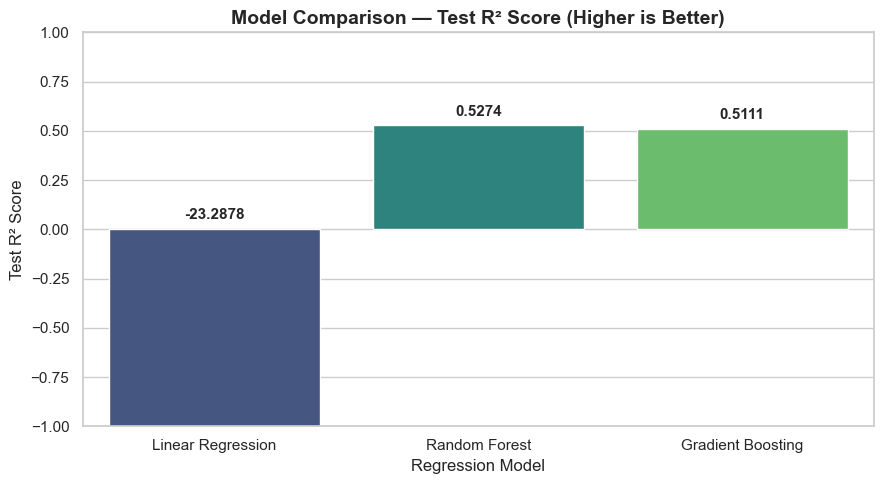

In [8]:
# Calculate R2 score on Training Data
r2_lr_train = r2_score(y_train, model_lr.predict(X_train))
r2_rf_train = r2_score(y_train, model_rf.predict(X_train))
r2_gb_train = r2_score(y_train, model_gb.predict(X_train))

# Calculate R2 score on Testing Data
r2_lr_test = r2_score(y_test, y_pred_lr)
r2_rf_test = r2_score(y_test, y_pred_rf)
r2_gb_test = r2_score(y_test, y_pred_gb)

# Create a comparison table DataFrame
model_comparison = pd.DataFrame({
    'Model Name': ['Linear Regression', 'Random Forest', 'Gradient Boosting'],
    'Train R² Score': [r2_lr_train, r2_rf_train, r2_gb_train],
    'Test R² Score': [r2_lr_test, r2_rf_test, r2_gb_test]
})

# Display comparison table
print("Model Comparison Summary:")
print(model_comparison.to_string(index=False))

# Plot bar chart comparing Test R² scores
plt.figure(figsize=(9, 5))
sns.barplot(data=model_comparison, x='Model Name', y='Test R² Score', hue='Model Name', palette='viridis', legend=False)
plt.title("Model Comparison — Test R² Score (Higher is Better)", fontsize=14, fontweight='bold')
plt.xlabel("Regression Model", fontsize=12)
plt.ylabel("Test R² Score", fontsize=12)
plt.ylim(-1.0, 1.0)

# Add score labels on top of bars
for index, row in model_comparison.iterrows():
    y_pos = max(0.05, row['Test R² Score'] + 0.05)
    plt.text(index, y_pos, f"{row['Test R² Score']:.4f}", 
             ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

---
# 9. Save Best Model (`joblib`)




In [9]:
# Step 1: Ensure models directory exists
models_dir = os.path.join("..", "models")
if not os.path.exists(models_dir):
    models_dir = os.path.join("models")

os.makedirs(models_dir, exist_ok=True)

# Step 2: Define file path for saving the best model
model_save_path = os.path.join(models_dir, "best_model.pkl")

# Select best performing model (Random Forest / Gradient Boosting)
best_model = model_rf if r2_rf_test >= r2_gb_test else model_gb

# Step 3: Save best model to disk using joblib
joblib.dump(best_model, model_save_path)

print(f"Best Model ({best_model.__class__.__name__}) saved successfully!")
print("Saved to file path:", model_save_path)

# Step 4: Verify saving by reloading the model back from disk
reloaded_model = joblib.load(model_save_path)

# Step 5: Test prediction with the reloaded model
reloaded_pred = reloaded_model.predict(X_test[:5])
print("\nVerification Test — Predictions from Reloaded Model:")
for i, pred in enumerate(reloaded_pred, 1):
    print(f"  House #{i}: ${pred:,.2f}")

Best Model (RandomForestRegressor) saved successfully!
Saved to file path: ..\models\best_model.pkl

Verification Test — Predictions from Reloaded Model:
  House #1: $141,512.45
  House #2: $203,775.66
  House #3: $147,012.17
  House #4: $208,984.73
  House #5: $195,723.21
